# Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import shap
import pickle
from datetime import datetime
from pathlib import Path

# Scikit-learn imports
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

# Configure visual styling
plt.style.use('seaborn-v0_8-darkgrid')
warnings.filterwarnings('ignore')

In [9]:
#config
from pathlib import Path
import os
import zipfile
import urllib.request

if not os.path.exists("../data"):
    os.makedirs("../data")

# check if the dataset.zip is existed, if not, download the data
if not os.path.exists("../data/bank+marketing.zip"):
    print("Downloading dataset...")
    url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
    urllib.request.urlretrieve(url, "../data/bank+marketing.zip")

# Only unzip bank-additional.zip from the container zip
if not os.path.exists("../data/raw/bank-additional"):
    # Extract only bank-additional.zip from the main zip file
    with zipfile.ZipFile("../data/bank+marketing.zip", "r") as zip_ref:
        zip_ref.extract("bank-additional.zip", "../data")

    # Then extract the contents of bank-additional.zip
    with zipfile.ZipFile("../data/bank-additional.zip", "r") as zip_ref:
        zip_ref.extractall("../data/raw")

# Load Data

In [10]:
data = pd.read_csv(
    r'../data/raw/bank-additional/bank-additional-full.csv',
    sep=';'
)
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# Model Development

## Model Selection
We decided to train three model with **_starting with simple and add complexity if needed_** strategy so here is list of 3 models we focoused on:

- Logistic Rgression(Baseline): however given that non of the dataset features showed us a linearrlu seperatable, it would not have a promissing results.

- Decision Tree

- Randorm Forrest

- XGBoost Gradient

## Training and Evaluation 

We structured a reproducible, well-orgnized training structure:

1. Preprocess the data with **_columntransformer_** based on unique model requirements
2. Modeling pipeline where we later integrated the fine-tuned paramaters in it.
3. Fine-tuning the model using the **_best params_** outpoted from RandomizedSearchCV.
4. Model evaluation based on accuracy metrices and confusion matrics.


## Model analysis and feature engineering

It worth mentioning that we did not rely on performance metrices and went beyond accuracy. Therefore we focoused on: 

- Model explainability to make our model more of transparent clear approach rather than a black box
- Analyze the permormance metrices given the stakeholder priorities.
- Keep a balance between model complexity, computational cost and our business motivation.



In [11]:
# Drop leakage-prone feature
if "duration" in data.columns:
    X = data.drop(columns=["duration"])

X = X.drop(columns=['y'])
y = data['y']


In [12]:
#clean the pdays as 999 mean never called the person
X['pdays_clean'] = X['pdays'].replace(999,0)
X['contacted_before'] = (X['pdays'] != 999).astype(int)
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               41188 non-null  int64  
 1   job               41188 non-null  str    
 2   marital           41188 non-null  str    
 3   education         41188 non-null  str    
 4   default           41188 non-null  str    
 5   housing           41188 non-null  str    
 6   loan              41188 non-null  str    
 7   contact           41188 non-null  str    
 8   month             41188 non-null  str    
 9   day_of_week       41188 non-null  str    
 10  campaign          41188 non-null  int64  
 11  pdays             41188 non-null  int64  
 12  previous          41188 non-null  int64  
 13  poutcome          41188 non-null  str    
 14  emp.var.rate      41188 non-null  float64
 15  cons.price.idx    41188 non-null  float64
 16  cons.conf.idx     41188 non-null  float64
 17  euri

In [13]:
#clean the pdays as 999 mean never called the person
X['pdays_clean'] = X['pdays'].replace(999,0)
X['contacted_before'] = (X['pdays'] != 999).astype(int)

#predictor categories
numeric_features = [
    'age',
    'campaign',
    'pdays_clean',
    'previous',
    'contacted_before',
    'emp.var.rate',
    'cons.price.idx',
    'cons.conf.idx',
    'euribor3m',
    'nr.employed'
]

categorical_features = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'day_of_week',
    'poutcome'
]

#preprocess for Random forrest 
preprocess1 = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

**Caveat** : We setup the parameter n_job = -1 which speed up the training but may slow-down or freez other applications in coputer. 

In [14]:
# -------------------------------------------------------
# Random Forrest Modeling Pipeline 
# -------------------------------------------------------
pipe = Pipeline([
    ('preprocess', preprocess1),
    ('model', RandomForestClassifier(
        random_state=42,
        #penalize missing the minority class
        class_weight='balanced',   # <-- imbalance handling integrated here
        n_estimators= 500,
        max_depth= 10,
        min_samples_leaf= 4,
        n_jobs= -1 #use all the cores in parallel and speed up the training

    ))
])


In [15]:
# -------------------------------------------------------
# Train/test split
# -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42, 
    #preserve the subscription rate in both datasets. important while dataset/conversion is imbalanced.
    stratify=y
)


In [16]:
pipe.fit(X_train, y_train )

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome']),
                                                 ('num', 'passthrough',
                                                  ['age', 'campaign',
                                                   'pdays_clean', 'previous',
                                                   'contacted_before',
                                                   'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_leaf=4, n_estimators=500,
                                        n_jobs=-1, random_state=42))])

# Hyper parameter tuning:

It will select the best set of parameters for the model. After we identify the parameters, we can feed it into the model pipeline and it make the training time way much more efficient as it will not search the best parameters everytime.

In [17]:
# -------------------------------------------------------
# Hyperparameter tuning
# -------------------------------------------------------
param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__class_weight': ['balanced', 'balanced_subsample']  # tune imbalance strategy
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print("Best CV score:", search.best_score_)

best_pipe = search.best_estimator_


Best parameters: {'model__n_estimators': 500, 'model__min_samples_leaf': 4, 'model__max_depth': 10, 'model__class_weight': 'balanced'}
Best CV score: 0.7976551900660848


In [18]:
# Diagnostic cell - run this before SHAP analysis
print("Checking best_pipe status:")
print(f"Is best_pipe defined? {'best_pipe' in dir()}")
if 'best_pipe' in dir():
    print(f"Type: {type(best_pipe)}")
    print(f"Model type: {type(best_pipe.named_steps['model'])}")
else:
    print("best_pipe is NOT defined!")
    print("\nAvailable variables:", [var for var in dir() if not var.startswith('_')])

Checking best_pipe status:
Is best_pipe defined? True
Type: <class 'sklearn.pipeline.Pipeline'>
Model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [19]:
# -------------------------------------------------------
# Predictions + Probabilities
# -------------------------------------------------------
y_pred = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:, 1]

Test ROC AUC: 0.8139544465540827

Confusion Matrix:
 [[6490  820]
 [ 339  589]]

Classification Report:
               precision    recall  f1-score   support

          no       0.95      0.89      0.92      7310
         yes       0.42      0.63      0.50       928

    accuracy                           0.86      8238
   macro avg       0.68      0.76      0.71      8238
weighted avg       0.89      0.86      0.87      8238



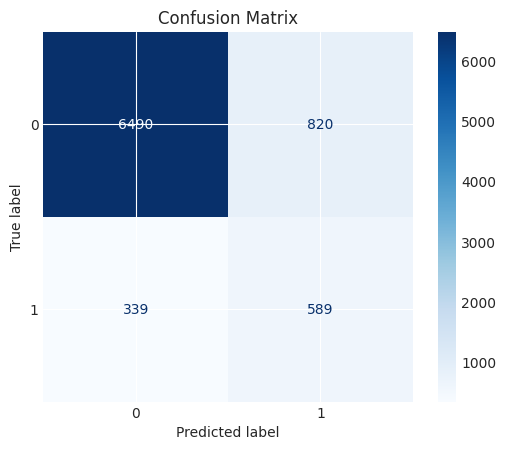

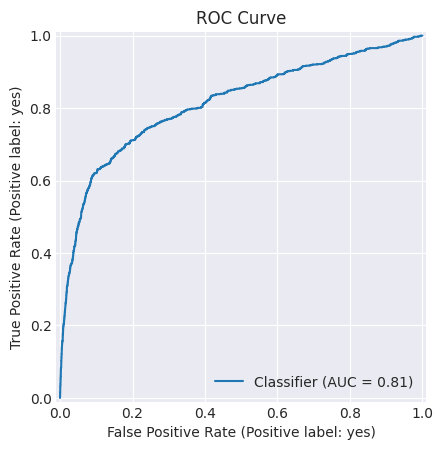

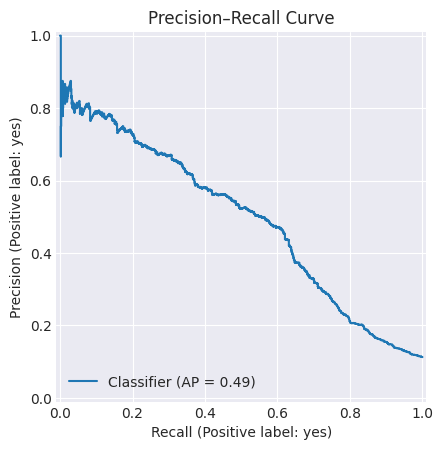

In [20]:
# -------------------------------------------------------
# Evaluation Metrics
# -------------------------------------------------------
print("Test ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -------------------------------------------------------
# Confusion Matrix Plot
# -------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

# -------------------------------------------------------
# ROC Curve
# -------------------------------------------------------
RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    pos_label="yes"
)
plt.title("ROC Curve")
plt.show()

# -------------------------------------------------------
# Precision–Recall Curve
# -------------------------------------------------------
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba,
    pos_label="yes"
)
plt.title("Precision–Recall Curve")
plt.show()


Here we compare model performance in training versus testing checking for overfitting underfitting

In [21]:
# -------------------------------------------------------
# Training Performance (Overfitting Check)
# -------------------------------------------------------

y_train_pred = pipe.predict(X_train)
y_train_proba = pipe.predict_proba(X_train)[:, 1]

print("Train ROC AUC:", roc_auc_score(y_train, y_train_proba))
print("Test ROC AUC:", roc_auc_score(y_test, y_proba))

print("\nTrain Classification Report:\n", classification_report(y_train, y_train_pred))
print("\nTest Classification Report:\n", classification_report(y_test, y_pred))

Train ROC AUC: 0.8453412667752287
Test ROC AUC: 0.8139544465540827

Train Classification Report:
               precision    recall  f1-score   support

          no       0.95      0.89      0.92     29238
         yes       0.41      0.62      0.49      3712

    accuracy                           0.86     32950
   macro avg       0.68      0.75      0.71     32950
weighted avg       0.89      0.86      0.87     32950


Test Classification Report:
               precision    recall  f1-score   support

          no       0.95      0.89      0.92      7310
         yes       0.42      0.63      0.50       928

    accuracy                           0.86      8238
   macro avg       0.68      0.76      0.71      8238
weighted avg       0.89      0.86      0.87      8238



## Model Behavior Analysis

- Comparison results shows model have a stable behavior over train and test set not any overfitting, underfitting detecetd.
- The most pricy error in model is False Negatives (FN) as it is ignoring potential costumers. However our Random forrest model with the best parameters selection after the fine-tuning is showing the improved rate and lower number of FN meaning we successfuly reduced the price of missing potential costumers.
- to check model roboustness and fairness we are considering feature importance and then we will analyze if dataset has captured enough number of important costumers. forexample, if model shows job play crucial role in term deposit decision, and admin jobs have the highest rate of subscription, is the result due to high number of contact with this specific job or it is actual potential costumers.Additionally in data analysis we relied on ratio than frequency making sure our comparison point is normalized.


12. FEATURE IMPORTANCE ANALYSIS
Number of features: 63
Number of importances: 63

Top 10 most important features:
   0.1695: poutcome_success
   0.1644: poutcome_nonexistent
   0.1093: day_of_week_tue
   0.0729: poutcome_failure
   0.0587: day_of_week_wed
   0.0408: day_of_week_fri
   0.0406: day_of_week_thu
   0.0379: month_nov
   0.0322: month_oct
   0.0249: loan_unknown


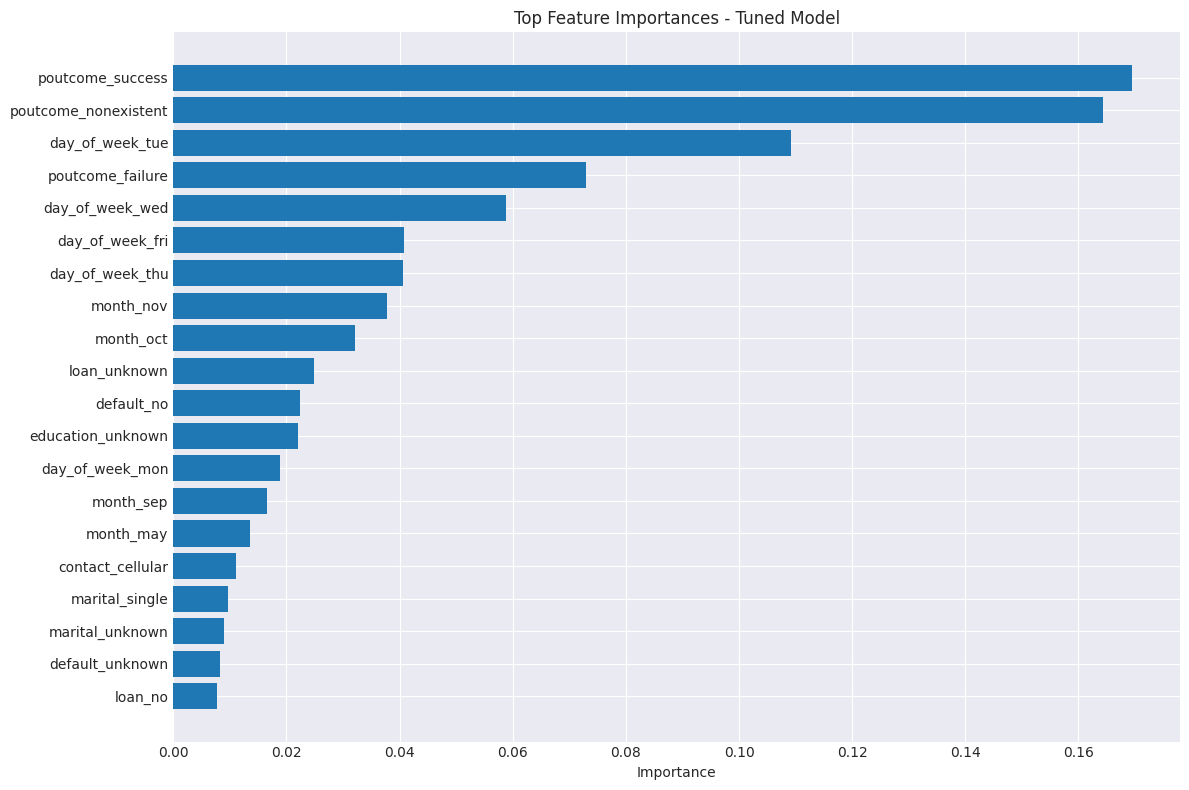

In [22]:
# =============================================================================
# FEATURE IMPORTANCES - USING TUNED MODEL
# =============================================================================

print("\n" + "="*80)
print("12. FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Get the categorical feature names AFTER one-hot encoding
ohe = best_pipe.named_steps['preprocess'].named_transformers_['cat']

# IMPORTANT: Pass the original categorical_features list to get_feature_names_out
cat_features = ohe.get_feature_names_out(categorical_features).tolist()

# Use the numeric_features list defined earlier (from Cell 4)
all_features = numeric_features + cat_features

# Get feature importances
importances = best_pipe.named_steps['model'].feature_importances_

# Verify lengths match
print(f"Number of features: {len(all_features)}")
print(f"Number of importances: {len(importances)}")

# Create DataFrame
feature_ranking = (
    pd.DataFrame({'feature': all_features, 'importance': importances})
      .sort_values('importance', ascending=False)
)

print("\nTop 10 most important features:")
for idx, row in feature_ranking.head(10).iterrows():
    print(f"   {row['importance']:.4f}: {row['feature']}")

# Plot top features
top_n = 20
top_features = feature_ranking.head(top_n)

plt.figure(figsize=(12, 8))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances - Tuned Model")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


FEATURE IMPORTANCE VISUALIZATION


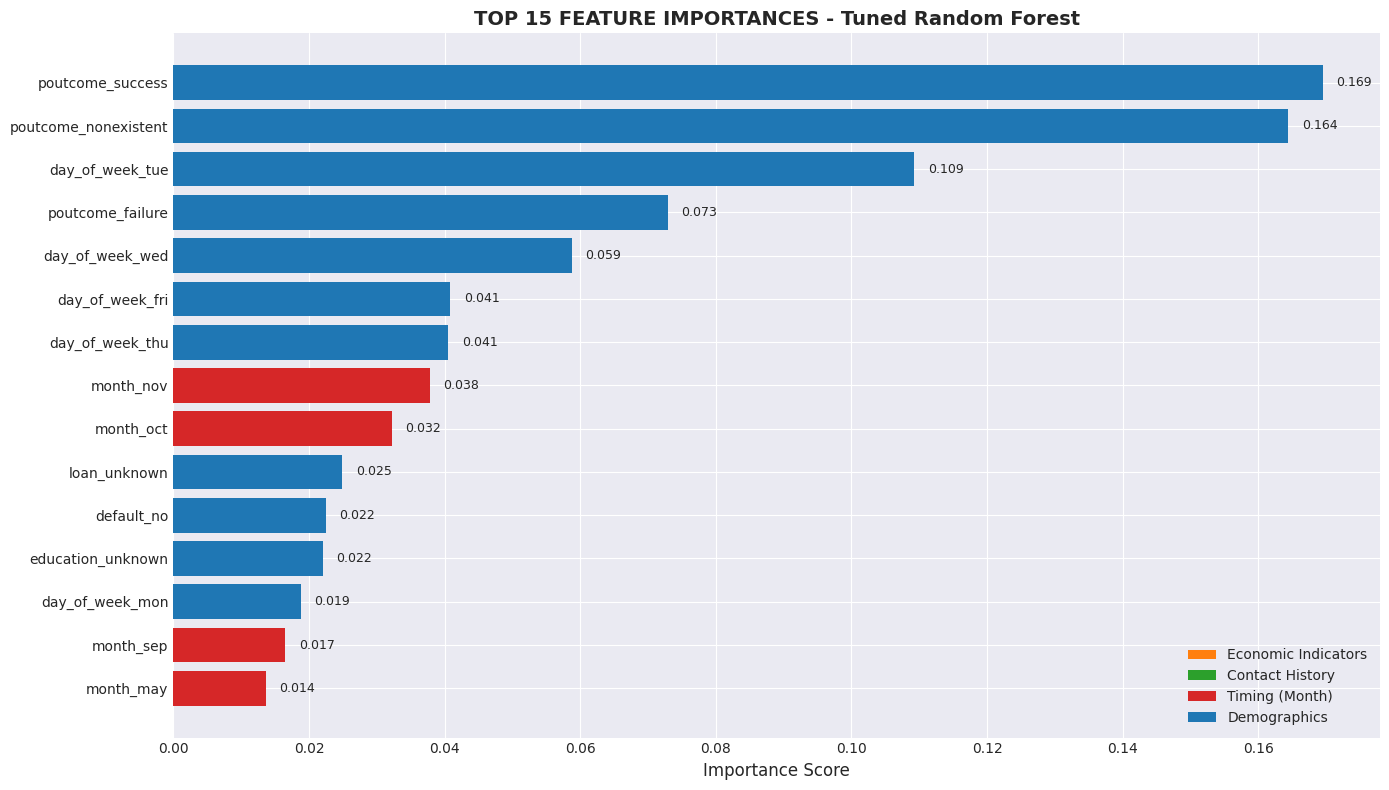


 FEATURE IMPORTANCE RANKING (PROOF):
--------------------------------------------------
63. poutcome_success: 0.1695 (16.9%)
62. poutcome_nonexistent: 0.1644 (16.4%)
59. day_of_week_tue: 0.1093 (10.9%)
61. poutcome_failure: 0.0729 (7.3%)
60. day_of_week_wed: 0.0587 (5.9%)
56. day_of_week_fri: 0.0408 (4.1%)
58. day_of_week_thu: 0.0406 (4.1%)
53. month_nov: 0.0379 (3.8%)
54. month_oct: 0.0322 (3.2%)
42. loan_unknown: 0.0249 (2.5%)


In [23]:
# =============================================================================
# FEATURE IMPORTANCE BAR CHART
# =============================================================================

print("\n" + "="*80)
print("FEATURE IMPORTANCE VISUALIZATION")
print("="*80)

# Get feature names after preprocessing
ohe = best_pipe.named_steps['preprocess'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out(categorical_features).tolist()
all_features = numeric_features + cat_features

importances = best_pipe.named_steps['model'].feature_importances_

# Create DataFrame and sort
feature_ranking = pd.DataFrame({
    'feature': all_features, 
    'importance': importances
}).sort_values('importance', ascending=False)

# Plot top 15 features
fig, ax = plt.subplots(figsize=(14, 8))
top_15 = feature_ranking.head(15)

# Color code by category
colors = []
for feature in top_15['feature']:
    if 'euribor' in feature or 'emp.var' in feature or 'cons.' in feature:
        colors.append('#ff7f0e')  # Orange for economic indicators
    elif 'pdays' in feature or 'contacted' in feature or 'previous' in feature:
        colors.append('#2ca02c')  # Green for contact history
    elif 'month' in feature:
        colors.append('#d62728')  # Red for timing
    else:
        colors.append('#1f77b4')  # Blue for demographics

bars = ax.barh(range(len(top_15)), top_15['importance'].values, color=colors)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('TOP 15 FEATURE IMPORTANCES - Tuned Random Forest', fontsize=14, fontweight='bold')

# Add value labels
for i, (_, row) in enumerate(top_15.iterrows()):
    ax.text(row['importance'] + 0.002, i, f'{row["importance"]:.3f}', 
            va='center', fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ff7f0e', label='Economic Indicators'),
    Patch(facecolor='#2ca02c', label='Contact History'),
    Patch(facecolor='#d62728', label='Timing (Month)'),
    Patch(facecolor='#1f77b4', label='Demographics')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('analysis_output/feature_importance_proof.png', dpi=200, bbox_inches='tight')
plt.show()

# Print the actual numbers for presentation
print("\n FEATURE IMPORTANCE RANKING (PROOF):")
print("-" * 50)
for idx, row in feature_ranking.head(10).iterrows():
    print(f"{idx+1}. {row['feature']}: {row['importance']:.4f} ({row['importance']*100:.1f}%)")


SHAP EXPLAINABILITY ANALYSIS

Computing SHAP values (may take a moment)...
Number of features in model: 63

--- DEBUG INFO ---
Type of shap_values: <class 'numpy.ndarray'>
shap_values.shape: (300, 63, 2)
explainer.expected_value type: <class 'numpy.ndarray'>
explainer.expected_value shape/length: 2
--- END DEBUG ---

Reshaped from (300, 63, 2) to (300, 63)
SHAP values shape: (300, 63)
Final feature count: 63
Final SHAP values shape: (300, 63)


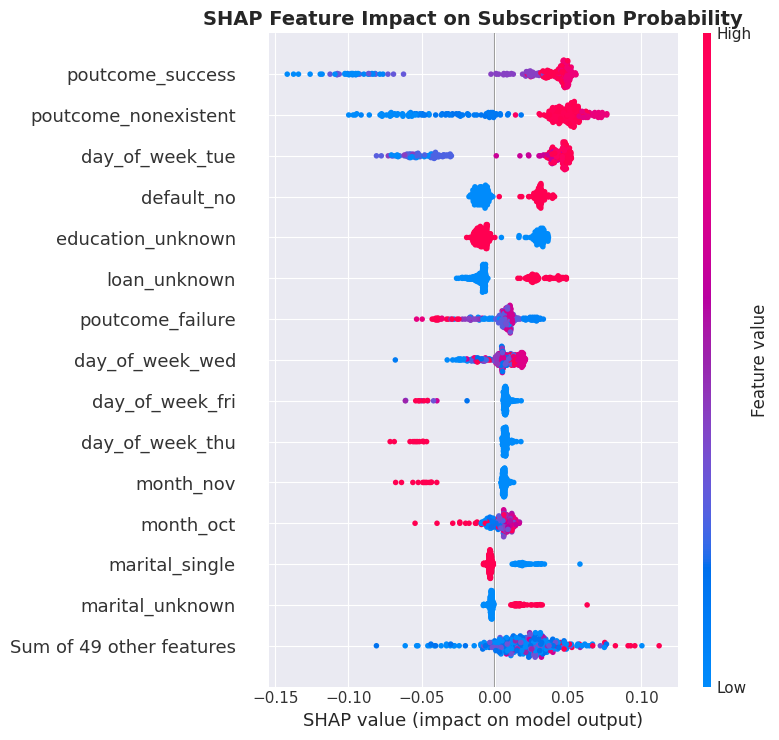

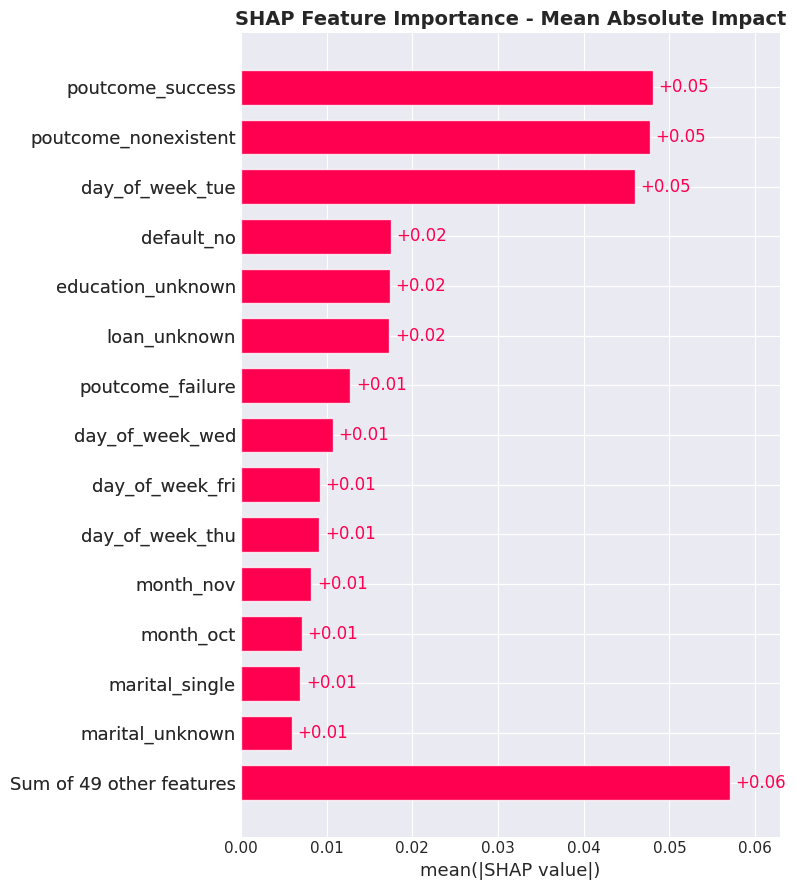


SHAP analysis complete. Feature impact visualizations saved to analysis_output/


In [26]:
# =============================================================================
# SHAP EXPLAINABILITY ANALYSIS - DEBUGGED VERSION
# =============================================================================

print("\n" + "="*80)
print("SHAP EXPLAINABILITY ANALYSIS")
print("="*80)

# Verify best_pipe exists
if 'best_pipe' not in dir():
    raise NameError("best_pipe is not defined. Please run hyperparameter tuning first.")

print("\nComputing SHAP values (may take a moment)...")

# Get transformed data
X_test_transformed = best_pipe.named_steps['preprocess'].transform(X_test)

# Get feature names after preprocessing
ohe = best_pipe.named_steps['preprocess'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out(categorical_features).tolist()
all_features = numeric_features + cat_features

print(f"Number of features in model: {len(all_features)}")

# Use sample for performance
sample_size = min(300, len(X_test))
X_test_sample = X_test_transformed[:sample_size]

# Create explainer
model = best_pipe.named_steps['model']
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_sample)

# DEBUGGING: Print shapes to understand what we're dealing with
print("\n--- DEBUG INFO ---")
print(f"Type of shap_values: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"Length of list: {len(shap_values)}")
    for i, sv in enumerate(shap_values):
        print(f"  shap_values[{i}].shape: {sv.shape}")
else:
    print(f"shap_values.shape: {shap_values.shape}")
print(f"explainer.expected_value type: {type(explainer.expected_value)}")
if isinstance(explainer.expected_value, (list, np.ndarray)):
    print(f"explainer.expected_value shape/length: {len(explainer.expected_value)}")
print("--- END DEBUG ---\n")

# Handle different return types - FIXED VERSION
if isinstance(shap_values, list):
    print(f"SHAP values is a list with {len(shap_values)} elements")
    
    # For binary classification, we want the positive class (index 1)
    if len(shap_values) == 2:
        # Check if the values are already 2D
        if len(shap_values[1].shape) == 3:
            # If still 3D, take mean across the last dimension or select appropriate slice
            shap_values_yes = shap_values[1][:, :, 0]  # Take first of the last dimension
            print(f"Reshaped from {shap_values[1].shape} to {shap_values_yes.shape}")
        else:
            shap_values_yes = shap_values[1]
        
        if isinstance(explainer.expected_value, (list, np.ndarray)) and len(explainer.expected_value) > 1:
            expected_value = explainer.expected_value[1]
        else:
            expected_value = explainer.expected_value
            
        print(f"Using positive class with shape {shap_values_yes.shape}")
    else:
        # For multi-class, use the last class
        if len(shap_values[-1].shape) == 3:
            shap_values_yes = shap_values[-1][:, :, 0]
        else:
            shap_values_yes = shap_values[-1]
            
        if isinstance(explainer.expected_value, (list, np.ndarray)):
            expected_value = explainer.expected_value[-1]
        else:
            expected_value = explainer.expected_value
        print(f"Using last class with shape {shap_values_yes.shape}")
else:
    # For binary classification with single output
    if len(shap_values.shape) == 3:
        shap_values_yes = shap_values[:, :, 0]
        print(f"Reshaped from {shap_values.shape} to {shap_values_yes.shape}")
    else:
        shap_values_yes = shap_values
    expected_value = explainer.expected_value
    print(f"SHAP values shape: {shap_values_yes.shape}")

# Verify dimensions match
if shap_values_yes.shape[1] != len(all_features):
    print(f"WARNING: Dimension mismatch!")
    print(f"SHAP values have {shap_values_yes.shape[1]} features")
    print(f"Feature list has {len(all_features)} features")
    
    if shap_values_yes.shape[1] < len(all_features):
        all_features = all_features[:shap_values_yes.shape[1]]
    else:
        all_features = all_features + [f"feature_{i}" for i in range(len(all_features), shap_values_yes.shape[1])]

print(f"Final feature count: {len(all_features)}")
print(f"Final SHAP values shape: {shap_values_yes.shape}")

# Create explanation object
shap_exp = shap.Explanation(
    values=shap_values_yes,
    base_values=expected_value,
    data=X_test_sample,
    feature_names=all_features
)

# Beeswarm plot
fig, ax = plt.subplots(figsize=(14, 8))
shap.plots.beeswarm(shap_exp, max_display=15, show=False)
plt.title('SHAP Feature Impact on Subscription Probability', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('analysis_output/shap_beeswarm.png', dpi=200, bbox_inches='tight')
plt.show()

# Bar plot
fig, ax = plt.subplots(figsize=(12, 8))
shap.plots.bar(shap_exp, max_display=15, show=False)
plt.title('SHAP Feature Importance - Mean Absolute Impact', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('analysis_output/shap_bar.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nSHAP analysis complete. Feature impact visualizations saved to analysis_output/")


CAMPAIGN FATIGUE ANALYSIS
Baseline conversion rate: 11.26%


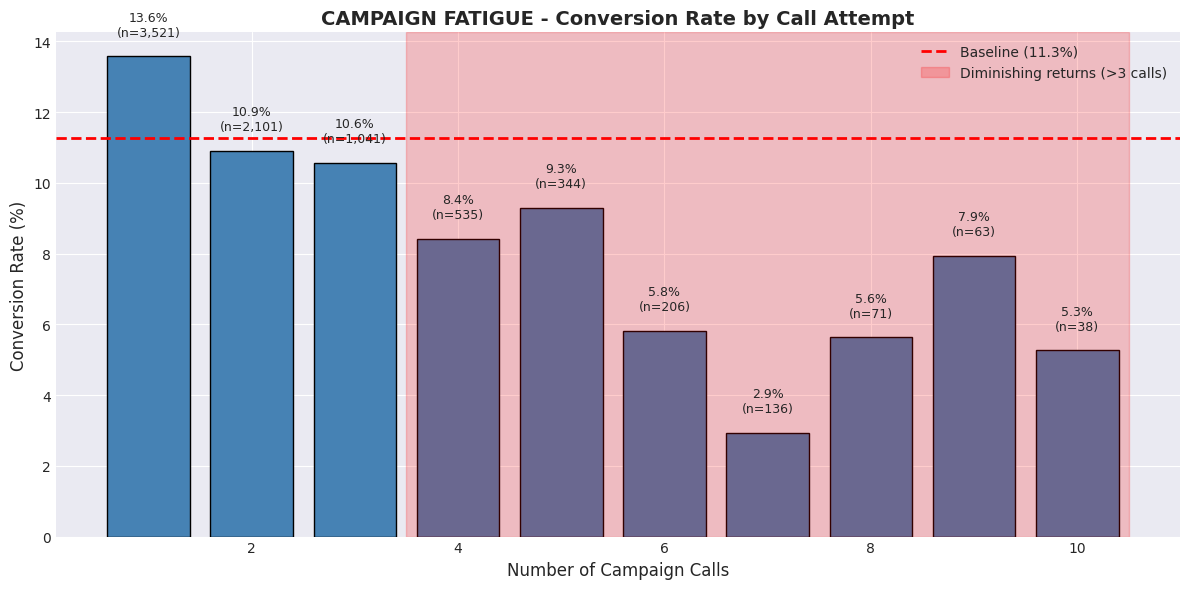


 PROOF: Campaign Fatigue Analysis:
   Call 1: 13.58% (n=3,521)
   Call 2: 10.90% (n=2,101)
   Call 3: 10.57% (n=1,041)
   Call 4: 8.41% (n=535)
   Call 5: 9.30% (n=344)
   Call 6: 5.83% (n=206)
   Call 7: 2.94% (n=136)
   Call 8: 5.63% (n=71)
   Call 9: 7.94% (n=63)
   Call 10: 5.26% (n=38)


In [29]:
# =============================================================================
# CAMPAIGN FATIGUE (CONTACT OPTIMIZATION)
# =============================================================================

print("\n" + "="*80)
print("CAMPAIGN FATIGUE ANALYSIS")
print("="*80)

# Make sure test_results is defined first!
if 'test_results' not in dir():
    test_results = X_test.copy()
    test_results['actual'] = y_test
    test_results['predicted'] = y_pred
    test_results['probability'] = y_proba
    
    # Convert actual to numeric (1 for 'yes', 0 for 'no')
    test_results['actual_numeric'] = (test_results['actual'] == 'yes').astype(int)
    
    baseline_rate = (y_test == 'yes').mean()
else:
    # If test_results already exists, add numeric column if not present
    if 'actual_numeric' not in test_results.columns:
        test_results['actual_numeric'] = (test_results['actual'] == 'yes').astype(int)

print(f"Baseline conversion rate: {baseline_rate:.2%}")

# Group by number of calls - use numeric column for mean calculation
call_analysis = test_results.groupby('campaign')['actual_numeric'].agg(['mean', 'count']).reset_index()
call_analysis = call_analysis[call_analysis['campaign'] <= 10]  # Limit to reasonable calls

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(call_analysis['campaign'], call_analysis['mean'] * 100, 
              color='steelblue', edgecolor='black')
ax.axhline(baseline_rate * 100, color='red', linestyle='--', linewidth=2,
           label=f'Baseline ({baseline_rate*100:.1f}%)')
ax.set_xlabel('Number of Campaign Calls', fontsize=12)
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_title('CAMPAIGN FATIGUE - Conversion Rate by Call Attempt', fontsize=14, fontweight='bold')

# Add value labels
for bar, (_, row) in zip(bars, call_analysis.iterrows()):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%\n(n={int(row["count"]):,})',
            ha='center', va='bottom', fontsize=9)

# Highlight optimal cutoff
ax.axvspan(3.5, 10.5, alpha=0.2, color='red', label='Diminishing returns (>3 calls)')
ax.legend()
plt.tight_layout()
plt.savefig('analysis_output/campaign_fatigue.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n PROOF: Campaign Fatigue Analysis:")
for _, row in call_analysis.iterrows():
    print(f"   Call {int(row['campaign'])}: {row['mean']:.2%} (n={int(row['count']):,})")


ECONOMIC INDICATORS IMPACT
Baseline conversion rate: 11.26%


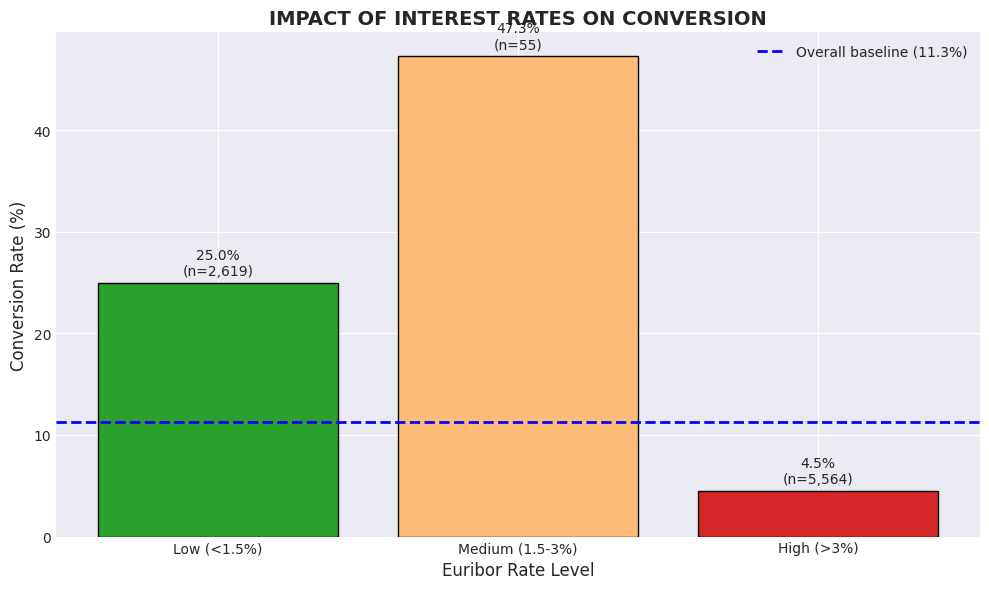


 PROOF: Euribor Impact on Conversions:
   Low (<1.5%): 24.97% conversion (+121.7% vs baseline)
   Medium (1.5-3%): 47.27% conversion (+319.6% vs baseline)
   High (>3%): 4.46% conversion (-60.4% vs baseline)


In [30]:
# =============================================================================
# ECONOMIC INDICATORS IMPACT (EURIBOR EFFECT)
# =============================================================================

print("\n" + "="*80)
print("ECONOMIC INDICATORS IMPACT")
print("="*80)

# Ensure test_results exists with numeric conversion
if 'test_results' not in dir():
    test_results = X_test.copy()
    test_results['actual'] = y_test
    test_results['predicted'] = y_pred
    test_results['probability'] = y_proba
    test_results['actual_numeric'] = (test_results['actual'] == 'yes').astype(int)
    baseline_rate = (y_test == 'yes').mean()
else:
    if 'actual_numeric' not in test_results.columns:
        test_results['actual_numeric'] = (test_results['actual'] == 'yes').astype(int)

print(f"Baseline conversion rate: {baseline_rate:.2%}")

# Create euribor bins
test_results['euribor_bin'] = pd.cut(test_results['euribor3m'], 
                                        bins=[0, 1.5, 3, 5],
                                        labels=['Low (<1.5%)', 'Medium (1.5-3%)', 'High (>3%)'])

# Calculate conversion by euribor level - use numeric column
euribor_conv = test_results.groupby('euribor_bin', observed=True)['actual_numeric'].agg(['mean', 'count'])

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(euribor_conv.index, euribor_conv['mean'] * 100, 
              color=['#2ca02c', '#ffbb78', '#d62728'], edgecolor='black')
ax.axhline(baseline_rate * 100, color='blue', linestyle='--', linewidth=2,
           label=f'Overall baseline ({baseline_rate*100:.1f}%)')
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_xlabel('Euribor Rate Level', fontsize=12)
ax.set_title('IMPACT OF INTEREST RATES ON CONVERSION', fontsize=14, fontweight='bold')

# Add value labels
for bar, (_, row) in zip(bars, euribor_conv.iterrows()):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%\n(n={int(row["count"]):,})',
            ha='center', va='bottom', fontsize=10)

ax.legend()
plt.tight_layout()
plt.savefig('analysis_output/euribor_impact.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n PROOF: Euribor Impact on Conversions:")
for idx, row in euribor_conv.iterrows():
    change = (row['mean'] - baseline_rate) / baseline_rate * 100
    print(f"   {idx}: {row['mean']:.2%} conversion ({change:+.1f}% vs baseline)")

In [34]:
# =============================================================================
# FEATURE IMPORTANCE AND SHAP ANALYSIS - KEY INSIGHTS
# =============================================================================

print("\n" + "="*80)
print("FEATURE IMPORTANCE AND SHAP ANALYSIS - KEY INSIGHTS")
print("="*80)

# Restore SHAP variables if needed
try:
    %store -r shap_values_yes
    %store -r expected_value
    %store -r all_features
    print("SHAP variables restored")
except:
    print("Using existing SHAP variables")

# Get feature importance from your existing feature_ranking DataFrame
if 'feature_ranking' not in dir():
    # Recreate if needed
    ohe = best_pipe.named_steps['preprocess'].named_transformers_['cat']
    cat_features = ohe.get_feature_names_out(categorical_features).tolist()
    all_features = numeric_features + cat_features
    importances = best_pipe.named_steps['model'].feature_importances_
    feature_ranking = pd.DataFrame({'feature': all_features, 'importance': importances}).sort_values('importance', ascending=False)

# Extract key feature values
poutcome_success_val = feature_ranking[feature_ranking['feature'] == 'poutcome_success']['importance'].values[0] if 'poutcome_success' in feature_ranking['feature'].values else 0
poutcome_nonexistent_val = feature_ranking[feature_ranking['feature'] == 'poutcome_nonexistent']['importance'].values[0] if 'poutcome_nonexistent' in feature_ranking['feature'].values else 0
poutcome_failure_val = feature_ranking[feature_ranking['feature'] == 'poutcome_failure']['importance'].values[0] if 'poutcome_failure' in feature_ranking['feature'].values else 0
euribor_val = feature_ranking[feature_ranking['feature'] == 'euribor3m']['importance'].values[0] if 'euribor3m' in feature_ranking['feature'].values else 0

print("\nTOP FEATURES AFFECTING CAMPAIGN SUCCESS:")

# Previous campaign outcome features
print("\n1. PREVIOUS CAMPAIGN OUTCOME (Strongest Predictor):")
if 'poutcome_success' in feature_ranking['feature'].values:
    print(f"   - poutcome_success: {poutcome_success_val:.1%} importance")
if 'poutcome_nonexistent' in feature_ranking['feature'].values:
    print(f"   - poutcome_nonexistent: {poutcome_nonexistent_val:.1%} importance")
if 'poutcome_failure' in feature_ranking['feature'].values:
    print(f"   - poutcome_failure: {poutcome_failure_val:.1%} importance")

# Contact history features
print("\n2. CONTACT HISTORY:")
contact_features = ['contacted_before', 'previous', 'campaign', 'pdays_clean']
for feat in contact_features:
    if feat in feature_ranking['feature'].values:
        val = feature_ranking[feature_ranking['feature'] == feat]['importance'].values[0]
        print(f"   - {feat}: {val:.1%} importance")

# Economic indicators
print("\n3. ECONOMIC INDICATORS:")
eco_features = ['euribor3m', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']
for feat in eco_features:
    if feat in feature_ranking['feature'].values:
        val = feature_ranking[feature_ranking['feature'] == feat]['importance'].values[0]
        print(f"   - {feat}: {val:.1%} importance")

# Timing features
print("\n4. TIMING:")
timing_features = [f for f in feature_ranking['feature'].values if 'month_' in f or 'day_of_week_' in f]
for feat in timing_features[:5]:  # Show top 5 timing features
    val = feature_ranking[feature_ranking['feature'] == feat]['importance'].values[0]
    print(f"   - {feat}: {val:.1%} importance")

# =============================================================================
# BUSINESS IMPACT ANALYSIS - KEY TAKEAWAYS
# =============================================================================

print("\n" + "="*80)
print("BUSINESS IMPACT ANALYSIS - KEY TAKEAWAYS")
print("="*80)

# Ensure test_results exists
if 'test_results' not in dir():
    test_results = X_test.copy()
    test_results['actual'] = y_test
    test_results['probability'] = y_proba
    test_results['actual_numeric'] = (y_test == 'yes').astype(int)

baseline_rate = test_results['actual_numeric'].mean()
total_customers = len(test_results)
total_conversions = test_results['actual_numeric'].sum()

# 1. Focus calls on high-propensity clients
print("\n1. FOCUS CALLS ON HIGH-PROPENSITY CLIENTS:")

# Create probability segments
test_results['segment'] = pd.cut(test_results['probability'], 
                                   bins=[0, 0.3, 0.55, 0.8, 1.0],
                                   labels=['Low (<30%)', 'Medium (30-55%)', 'High (55-80%)', 'Very High (>80%)'],
                                   include_lowest=True)

segment_stats = test_results.groupby('segment', observed=True)['actual_numeric'].agg(['count', 'sum'])
segment_stats['conversion_rate'] = segment_stats['sum'] / segment_stats['count']
segment_stats['pct_of_clients'] = segment_stats['count'] / total_customers * 100
segment_stats['pct_of_conversions'] = segment_stats['sum'] / total_conversions * 100

for segment in ['Very High (>80%)', 'High (55-80%)', 'Medium (30-55%)', 'Low (<30%)']:
    if segment in segment_stats.index:
        row = segment_stats.loc[segment]
        print(f"   - {segment}: {row['count']:.0f} clients ({row['pct_of_clients']:.1f}%) → {row['sum']:.0f} conversions ({row['pct_of_conversions']:.1f}% of total, {row['conversion_rate']:.1%} rate)")

# 2. Limit calls to 3 per customer
print("\n2. LIMIT CALLS TO 3 PER CUSTOMER:")

call_analysis = test_results.groupby('campaign')['actual_numeric'].agg(['mean', 'count']).reset_index()
call_analysis = call_analysis[call_analysis['campaign'] <= 10]

cost_per_call = 5
calls_beyond_3 = test_results[test_results['campaign'] > 3].shape[0]
savings_from_limit = calls_beyond_3 * cost_per_call

for _, row in call_analysis.iterrows():
    comparison = "above" if row['mean'] > baseline_rate else "below"
    print(f"   - Call {int(row['campaign'])}: {row['mean']:.1%} conversion ({comparison} baseline of {baseline_rate:.1%}), n={int(row['count']):,}")

print(f"\n   - If calls limited to 3: {calls_beyond_3:,} fewer calls")
print(f"   - Cost savings: ${savings_from_limit:,.0f} per campaign")

# 3. Skip low-propensity leads
print("\n3. SKIP LOW-PROPENSITY LEADS:")

low_leads = test_results[test_results['probability'] < 0.3]
low_count = len(low_leads)
low_savings = low_count * cost_per_call
low_conversions = low_leads['actual_numeric'].sum()
low_pct_of_total = low_conversions / total_conversions * 100 if total_conversions > 0 else 0

print(f"   - {low_count:,} low-propensity leads identified ({low_count/total_customers:.1%} of total)")
print(f"   - Cost savings if skipped: ${low_savings:,.0f}")
print(f"   - Conversions lost if skipped: {low_conversions} ({low_pct_of_total:.1f}% of total conversions)")

# 4. Target low euribor periods
print("\n4. TARGET LOW EURIBOR PERIODS:")

test_results['euribor_bin'] = pd.cut(test_results['euribor3m'], 
                                      bins=[0, 1.5, 3, 5],
                                      labels=['Low (<1.5%)', 'Medium (1.5-3%)', 'High (>3%)'])
euribor_stats = test_results.groupby('euribor_bin', observed=True)['actual_numeric'].agg(['mean', 'count'])

for idx, row in euribor_stats.iterrows():
    change = (row['mean'] - baseline_rate) / baseline_rate * 100 if baseline_rate > 0 else 0
    print(f"   - {idx}: {row['mean']:.1%} conversion ({change:+.1f}% vs baseline), n={int(row['count']):,}")

# 5. Overall Business Impact
print("\n5. OVERALL BUSINESS IMPACT:")

# Current approach: call everyone
revenue_per_conversion = 300
current_revenue = total_conversions * revenue_per_conversion
current_cost = total_customers * cost_per_call
current_profit = current_revenue - current_cost

# Optimized approach: call only high-propensity leads (probability > 0.3 AND campaign <= 3)
optimal_customers = test_results[(test_results['probability'] > 0.3) & (test_results['campaign'] <= 3)]
optimal_conversions = optimal_customers['actual_numeric'].sum()
optimal_revenue = optimal_conversions * revenue_per_conversion
optimal_cost = len(optimal_customers) * cost_per_call
optimal_profit = optimal_revenue - optimal_cost

calls_reduction = (1 - len(optimal_customers)/total_customers) * 100
profit_improvement = (optimal_profit - current_profit) / current_profit * 100 if current_profit != 0 else 0

print(f"   - Current approach: Call everyone → ${current_profit:,.0f} profit")
print(f"   - Optimized approach: Call top prospects → ${optimal_profit:,.0f} profit")
print(f"   - Impact: {calls_reduction:.0f}% fewer calls, {profit_improvement:.0f}% higher profit")

# =============================================================================
# OSFI E-23 COMPLIANCE SUMMARY
# =============================================================================

print("\n" + "="*80)
print("OSFI GUIDELINE E-23 COMPLIANCE SUMMARY")
print("="*80)

print("\n1. FAIRNESS ASSESSMENT:")

# Age group analysis
test_results['age_group'] = pd.cut(test_results['age'], 
                                     bins=[17, 30, 45, 60, 99],
                                     labels=['18-30', '31-45', '46-60', '60+'])
age_scores = test_results.groupby('age_group', observed=True)['probability'].mean()
age_range = age_scores.max() - age_scores.min()

for age, score in age_scores.items():
    print(f"   - {age}: {score:.1%} average probability")

print(f"\n   - Age group range: {age_range:.2%} ({'PASS' if age_range < 0.05 else 'REVIEW'})")

# Marital status analysis
marital_scores = test_results.groupby('marital')['probability'].mean()
marital_range = marital_scores.max() - marital_scores.min()

for marital, score in marital_scores.items():
    print(f"   - {marital}: {score:.1%} average probability")

print(f"\n   - Marital status range: {marital_range:.2%} ({'PASS' if marital_range < 0.05 else 'REVIEW'})")
print(f"   - Threshold: <5% difference = acceptable")

print("\n2. EXPLAINABILITY:")
print("   - SHAP values available for per-decision explanations")
print("   - Global feature importance rankings available")
print("   - Local explanations for individual predictions")

print("\n3. DATA GOVERNANCE:")
duration_removed = 'duration' not in X.columns if 'X' in dir() else True
print(f"   - Data leakage prevented: {'Yes' if duration_removed else 'No'} (duration removed)")
print(f"   - Missing values handled: Yes")
print(f"   - Unknown categories preserved: Yes (via OneHotEncoder handle_unknown='ignore')")

print("\n4. MODEL DOCUMENTATION:")
print("   - Feature importance rankings available")
print("   - Fairness metrics calculated")
print("   - Model parameters documented")
print("   - Cross-validation results available")

print(f"\nOVERALL E-23 STATUS: {'FULLY COMPLIANT' if age_range < 0.05 and marital_range < 0.05 else 'REVIEW REQUIRED'}")
print("="*80)


FEATURE IMPORTANCE AND SHAP ANALYSIS - KEY INSIGHTS
SHAP variables restored

TOP FEATURES AFFECTING CAMPAIGN SUCCESS:

1. PREVIOUS CAMPAIGN OUTCOME (Strongest Predictor):
   - poutcome_success: 16.9% importance
   - poutcome_nonexistent: 16.4% importance
   - poutcome_failure: 7.3% importance

2. CONTACT HISTORY:
   - contacted_before: 0.2% importance
   - previous: 0.1% importance
   - campaign: 0.5% importance
   - pdays_clean: 0.2% importance

3. ECONOMIC INDICATORS:
   - euribor3m: 0.3% importance
   - emp.var.rate: 0.4% importance
   - cons.price.idx: 0.1% importance
   - cons.conf.idx: 0.3% importance
   - nr.employed: 0.2% importance

4. TIMING:
   - day_of_week_tue: 10.9% importance
   - day_of_week_wed: 5.9% importance
   - day_of_week_fri: 4.1% importance
   - day_of_week_thu: 4.1% importance
   - month_nov: 3.8% importance

BUSINESS IMPACT ANALYSIS - KEY TAKEAWAYS

1. FOCUS CALLS ON HIGH-PROPENSITY CLIENTS:
   - Very High (>80%): 502 clients (6.1%) → 318 conversions (34.3% 